# 05. Visualizing the Kleene ascent

This notebook reproduces the structure of Fig. 36 from Censi (2015): plotting each antichain $S_k$ of the Kleene iteration as it converges, for the integer-optimization problem from notebook **02**.

We render the trace for three values of $c$ ($c = 1, 4, 8$). The seed is always $\{(0,0)\}$; the iteration grows the antichain outward along the diagonal $x + y \approx 2\sqrt{x+y} + c$ until it stabilises.


## Imports

In [1]:
import math
import matplotlib.pyplot as plt

from codesign import (
    Antichain, FunctionDP, Loop, NamedProduct, Naturals, solve,
)

%matplotlib inline

## The same model as notebook 02

In [2]:
def make_looped(c_value):
    N = Naturals()
    XY = NamedProduct({"x": N, "y": N})
    F = NamedProduct({"c": N, "xy": XY})
    R = NamedProduct({"xy": XY, "xy_report": XY})

    def h(f):
        c = int(f["c"])
        x_in, y_in = f["xy"]["x"], f["xy"]["y"]
        if x_in == math.inf or y_in == math.inf:
            top = {"x": math.inf, "y": math.inf}
            return Antichain.singleton(R, {"xy": top, "xy_report": top})
        sx = math.isqrt(int(x_in)) + (1 if math.isqrt(int(x_in))**2 < int(x_in) else 0)
        sy = math.isqrt(int(y_in)) + (1 if math.isqrt(int(y_in))**2 < int(y_in) else 0)
        target = sx + sy + c
        pts = []
        for x_out in range(sx, target - sy + 1):
            y_out = target - x_out
            if y_out < sy:
                break
            pts.append({
                "xy": {"x": x_out, "y": y_out},
                "xy_report": {"x": x_out, "y": y_out},
            })
        if not pts:
            return Antichain.empty(R)
        return Antichain.from_set(R, pts)
    return Loop(FunctionDP(F=F, R=R, h_fn=h), axis="xy")

## Plot the trace for a given c

In [3]:
def plot_trace(c_value):
    looped = make_looped(c_value)
    result = solve(looped, {"c": c_value}, max_iter=50, record_trace=True)
    trace = result.trace

    max_xy = 1
    for entry in trace:
        for p in entry.antichain.points:
            x, y = p["xy"]["x"], p["xy"]["y"]
            if x != math.inf: max_xy = max(max_xy, int(x))
            if y != math.inf: max_xy = max(max_xy, int(y))
    bound = max_xy + 3

    n = len(trace)
    cols = min(3, n); rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 3.0 * rows))
    axes = [axes] if rows * cols == 1 else (axes.flat if rows > 1 else axes)
    axes = list(axes)

    for k, entry in enumerate(trace):
        A = entry.antichain
        ax = axes[k]
        xs, ys = [], []
        for p in A.points:
            x, y = p["xy"]["x"], p["xy"]["y"]
            if x == math.inf or y == math.inf: continue
            xs.append(x); ys.append(y)
        ax.scatter(xs, ys, s=60, c="C3", zorder=3)
        ax.set_xlim(-0.5, bound); ax.set_ylim(-0.5, bound)
        ax.set_xticks(range(0, bound + 1, max(1, bound // 6)))
        ax.set_yticks(range(0, bound + 1, max(1, bound // 6)))
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.set_aspect("equal")
        ax.set_title(f"$S_{{{k}}}$ ({len(A.points)} pts)")
        ax.set_xlabel("x"); ax.set_ylabel("y")
    for k in range(len(trace), len(axes)):
        axes[k].set_visible(False)
    fig.suptitle(
        f"Kleene ascent for c = {c_value}: "
        f"converged in {result.iterations} iters, "
        f"|M| = {len(result.antichain.points)}",
        fontsize=11,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()
    return result

## c = 1

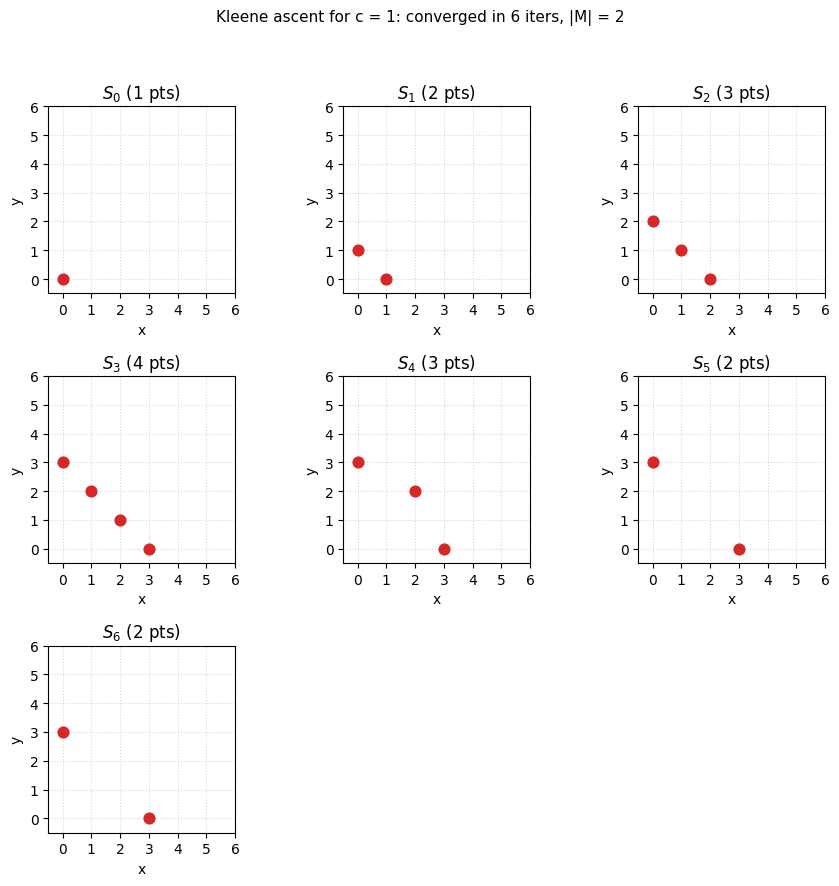

In [4]:
_ = plot_trace(1)

## c = 4 (the example from Fig. 36)

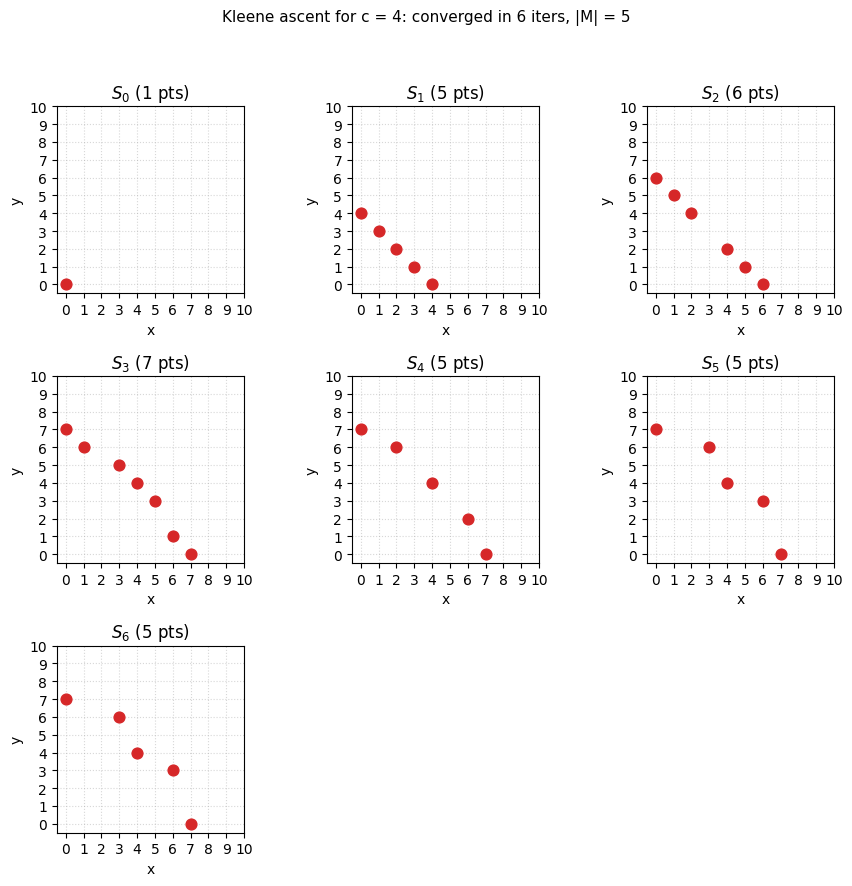

In [5]:
_ = plot_trace(4)

## c = 8

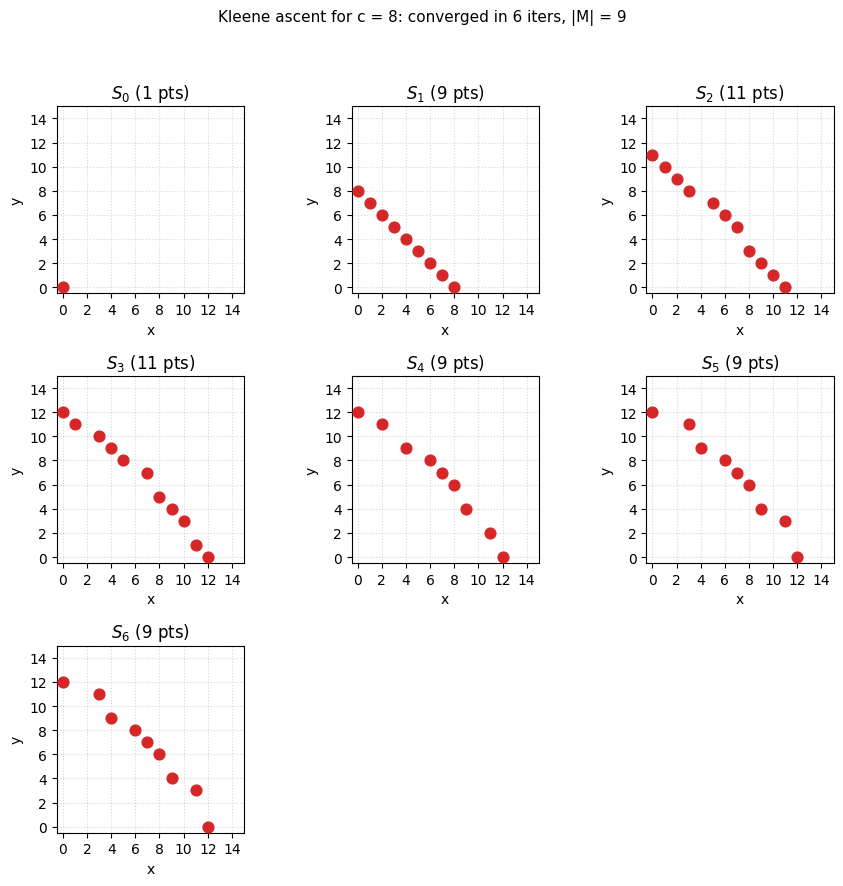

In [6]:
_ = plot_trace(8)

## Reading the plots

Every step of the iteration is monotone-non-decreasing in the antichain order: each point grows or splits into incomparable successors; nothing ever moves "down" in the poset. The number of points can fluctuate (some interior points get dominated by points discovered nearby), but the final antichain dominates the seed.

For this problem the iteration converges in O($\sqrt{c}$) steps because the diagonal grows by roughly $\Delta(x+y) \approx 2$ per iteration.
